
<p style="text-align:center;">
<kbd>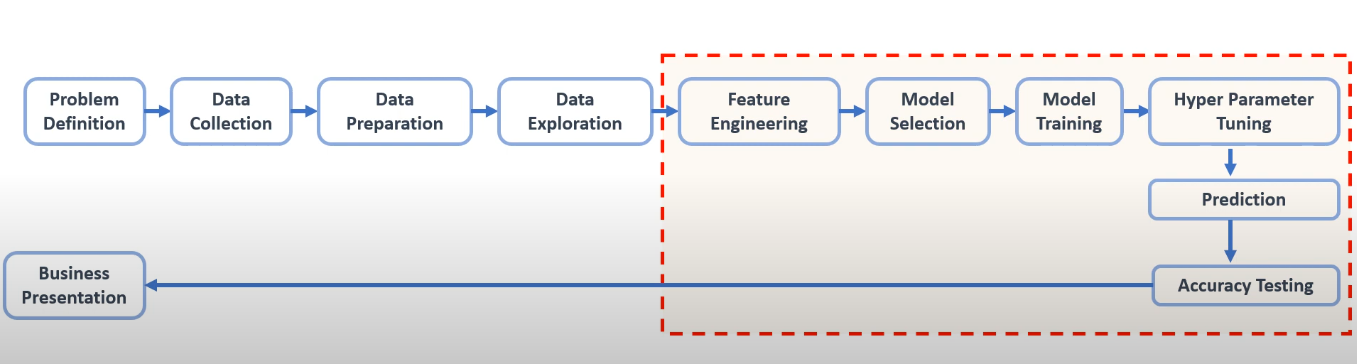<kbd></p>

### - Lazypredict : Only finds algorithms (without hyper-parameters).

### - GridSearchCV/RandomSearchCV : Can find hyper-parameters, BUT only if specified manually.

### ==> Lazypredict + GridSearchCV/RandomSearchCV :  Very slow + not accurate.

# AutoML ( CUDF + TPOT AutoML )

#### TPOT stands for Tree-based Pipeline Optimization Tool. Consider TPOT your Data Science Assistant. TPOT is a Python Automated Machine Learning tool that optimizes machine learning pipelines using **"genetic programming"**.


<p style="text-align:center;">
<kbd><img src="https://raw.githubusercontent.com/EpistasisLab/tpot/master/images/tpot-logo.jpg" width="200"
    align="center"><kbd></p>


<p style="text-align:center;">
<kbd>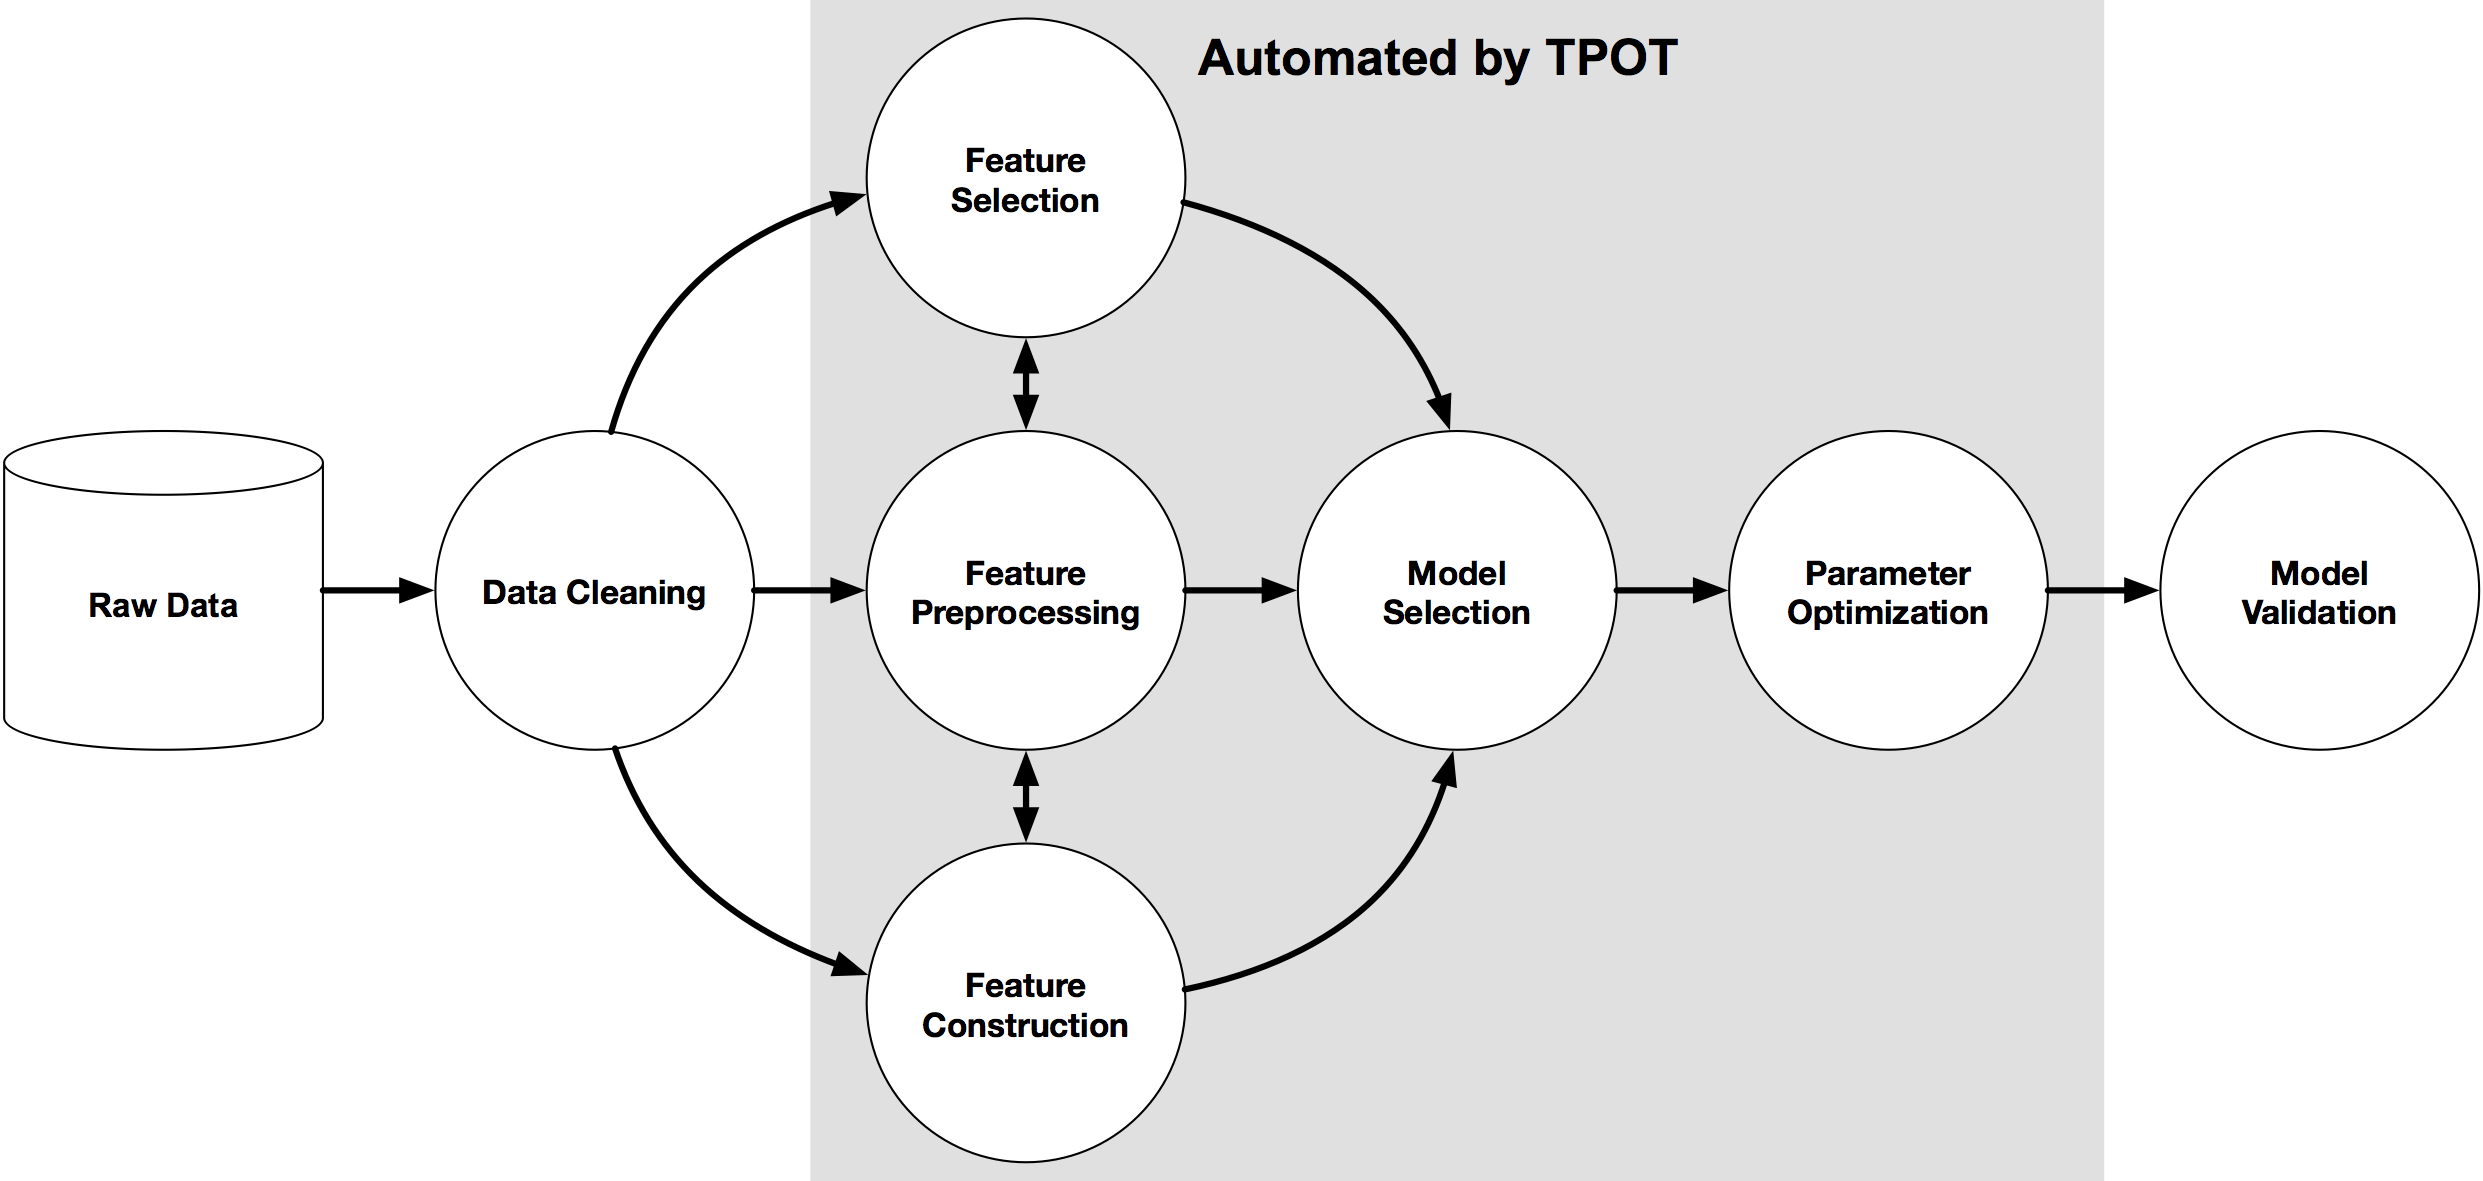<kbd></p>
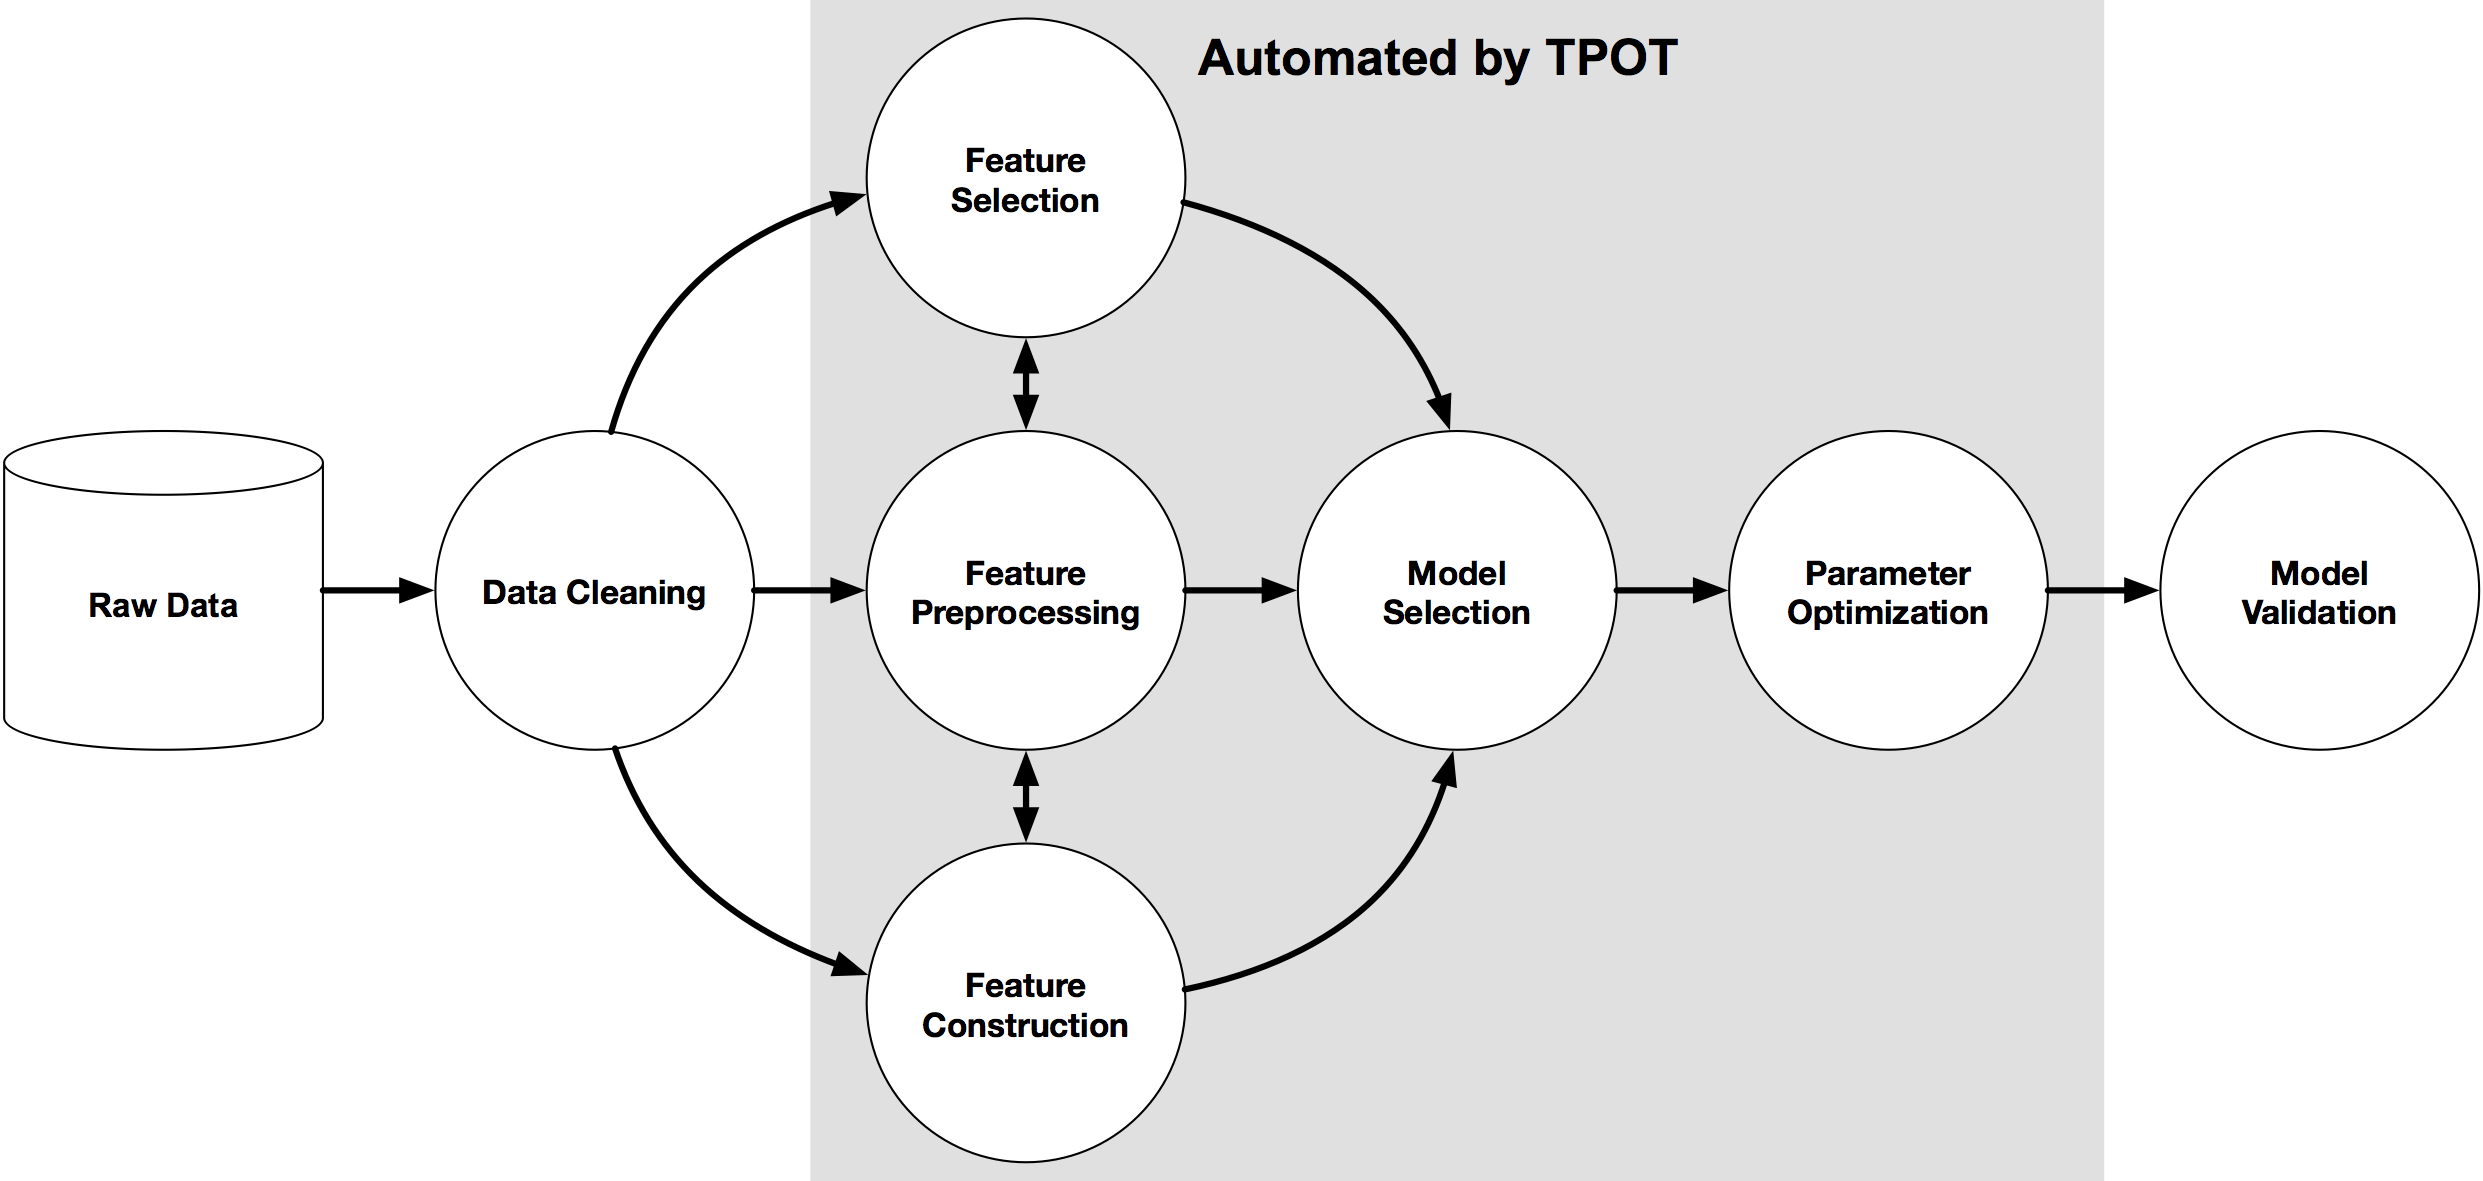

In [11]:
import pandas as pd 
import warnings
import cudf
from tpot import TPOTClassifier

import torch

In [ ]:
import torch

# Warnings CuDF


## 1.Read csv

In [2]:
data_cpu = pd.read_csv('/kaggle/input/student-score/StudentScore.xls')
print(data_cpu.info())

data_gpu = cudf.read_csv('/kaggle/input/student-score/StudentScore.xls')
print(data_gpu.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   

In [4]:
#------------------------ fix ----------------------------

data = pd.read_csv("/kaggle/input/student-score/StudentScore.xls")
data = cudf.DataFrame.from_pandas(data)
print(data.info())

a = ['1', '2', '5']
a_int = list(map(int, a))

print(a_int)  


<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), object(5)
memory usage: 83.9+ KB
None
[1, 2, 5]


# Code

In [2]:
data = cudf.read_csv('/kaggle/input/1-3m-linkedin-jobs-and-skills-2024/linkedin_job_postings.csv')
data = data.dropna()

print(data.info())


<class 'cudf.core.dataframe.DataFrame'>
Index: 1348424 entries, 0 to 1348453
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   job_link             1348424 non-null  object
 1   last_processed_time  1348424 non-null  object
 2   got_summary          1348424 non-null  object
 3   got_ner              1348424 non-null  object
 4   is_being_worked      1348424 non-null  object
 5   job_title            1348424 non-null  object
 6   company              1348424 non-null  object
 7   job_location         1348424 non-null  object
 8   first_seen           1348424 non-null  object
 9   search_city          1348424 non-null  object
 10  search_country       1348424 non-null  object
 11  search_position      1348424 non-null  object
 12  job_level            1348424 non-null  object
 13  job_type             1348424 non-null  object
dtypes: object(14)
memory usage: 424.4+ MB
None


In [8]:
from cuml.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

encoder = LabelEncoder()

for col in data:
    data[col] = encoder.fit_transform(data[col])

print(data.info())


y = data["job_level"]
x = data.drop("job_level", axis=1)


x_train, x_test, y_train, y_test = train_test_split(x, y,train_size=0.75, test_size=0.25)

In [9]:
print(type(x)) 
print(type(y)) 
print(type(x_train)) 
print(type(y_train)) 


<class 'cudf.core.dataframe.DataFrame'>
<class 'cudf.core.series.Series'>
<class 'cudf.core.dataframe.DataFrame'>
<class 'cudf.core.series.Series'>


In [10]:
tpot=TPOTClassifier( generations=3,
   population_size=2,
   config_dict="TPOT cuML",
   memory='auto',
   scoring='roc_auc',
   max_time_mins=40,
   cv=2,
   verbosity=2)

tpot.fit(x_train.to_numpy(), y_train.to_numpy())
print(tpot.score(x_test.to_numpy(), y_test.to_numpy()))



Version 0.12.1 of tpot is outdated. Version 0.12.2 was released Friday February 23, 2024.


Optimization Progress:   0%|          | 0/2 [00:00<?, ?pipeline/s]

[I] [12:40:59.110574] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [12:41:23.599819] Unused keyword parameter: n_jobs during cuML estimator initialization
[W] [12:41:52.243345] L-BFGS line search failed (code 4); stopping at the last valid step
[W] [12:41:52.541078] L-BFGS line search failed (code 4); stopping at the last valid step
[W] [12:41:52.776833] L-BFGS line search failed (code 4); stopping at the last valid step

Generation 1 - Current best internal CV score: 0.8839881832442102

Generation 2 - Current best internal CV score: 0.8839881832442102

Generation 3 - Current best internal CV score: 0.8947529042693417

Best pipeline: XGBClassifier(XGBClassifier(input_matrix, alpha=10, learning_rate=0.5, max_depth=6, min_child_weight=17, n_estimators=100, n_jobs=1, subsample=0.4, tree_method=gpu_hist, verbosity=0), alpha=10, learning_rate=0.1, max_depth=8, min_child_weight=7, n_estimators=100, n_jobs=1, subsample=0.8, tree_method=gpu_hist, verbosity=0)
0.905

# Note

1. Github tpot: https://github.com/epistasislab/tpot?tab=readme-ov-file
2. TPOT API: https://epistasislab.github.io/tpot/api/
3. Install: https://epistasislab.github.io/tpot/installing/
4. cuML: https://docs.rapids.ai/api/cuml/stable/cuml_intro/